# Load libraries

**NOTE**: `tensorflow` and `keras` are *only* used to be able to import the MNIST dataset

In [1]:
import numpy as np
import matplotlib.pyplot as PLT

from scipy.special import softmax,logsumexp

import tensorflow as tf
from tensorflow import keras

# Download data

In [2]:
from tensorflow.keras.datasets import mnist

# Training / validation data + labels
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print('Shape (training data):', x_train.shape)
print('Shape (valid/testing data):', x_valid.shape)


Shape (training data): (60000, 28, 28)
Shape (valid/testing data): (10000, 28, 28)


### Data pre-processing (normalization, etc.)

In [3]:
def stdPreproc(dIn,L=255.0, flagNorm=True, flagMean=True):

    dIn = dIn.astype("float")
    
    if flagNorm:
       dIn = dIn/L

    if flagMean:
       mean = np.mean(dIn, axis = 0)
       dIn -= mean
    
    return(dIn)

x_train = stdPreproc(x_train)
x_valid = stdPreproc(x_valid)

#### Visualization of a random element

Shape: (28, 28) label: 6


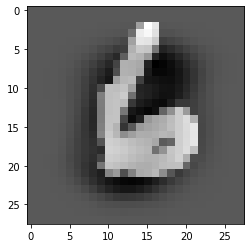

In [4]:
k = np.random.randint(0,x_train.shape[0])
    
PLT.imshow(x_train[k], cmap='gray')
print('Shape:',x_train[k].shape, 'label:', y_train[k])


#### Data vectorization

In [5]:
x_train = np.transpose( x_train.reshape(x_train.shape[0], x_train.shape[1]*x_train.shape[2]) )
x_valid = np.transpose( x_valid.reshape(x_valid.shape[0], x_valid.shape[1]*x_valid.shape[2]) )

# NOTE: in order to be consistant with lectures, then these matrices must be transposed


# Functions

Some useful functions are included here. For a full explanation see **Lecture 3b's Introduction**.

In [6]:
def softmax_L2_cost(X, Y, W, lmbd):

    fCost = np.sum(np.log(np.sum(np.exp(-X.transpose().dot(W)), axis=1)))
    fCost += np.sum( X*W[:,Y] )
    
    fCost /= float(X.shape[1])
    
    if lmbd > 0:
       fCost += lmbd*(sum( np.power(W.ravel(),2) ))
    
    return fCost

def softmax_L2_grad(X, Y, W, n, lmbd):
    
    z = X[:,np.ix_(n)].squeeze(1)      # select batch elements

    g = -z.dot( softmax(-z.transpose().dot(W),axis=1) )
    
    for k in range(len(n)):
        g[:,Y[n[k]] ] += z[:,k] 

    g /= float(len(n))  
    
    if lmbd > 0:
       g += lmbd*W
        
    return g
    
    
softmax_cost = lambda X,Y,W : softmax_L2_cost(X, Y, W, 0.)

softmax_grad = lambda X,Y,W,n : softmax_L2_grad(X, Y, W, n, 0.)
    
    

In [7]:
def computeSuccessSoftMax(X, Y, W):

    clase = -np.matmul(X.transpose(), W) 
    success = sum( np.argmax(clase,axis=1) == Y )
                
    return float(success)/float(X.shape[1])    
        
    

***

## Routines for SGD and variants

In [8]:

def stochGD(X, Y, nEpochs, NetArch, alpha0=0.01, blkSize=32, flagVerbose=10):
    
    # NetArch is a class (or dictionary) that implemnts specific function (e.g. cost, grad, etc.) for 
    # a particular problem, e.g. SoftMax classification
 
    # W : use a random matrix
    # stats : at least, 'train loss' (cost functional)
    
    nBlk = np.floor_divide(X.shape[1],blkSize)         
    
    for e in range(nEpochs):

      # Generate permutation
      blkInd = 0
      perm = np.random.permutation(X.shape[1])
     
                
      for b in range(nBlk):
        
        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:blkInd+blkSize]
        blkInd += blkSize
        
    
    
    return(W, statsSGD)  


## Test 

In [ ]:

# NetArch is a class (or dictionary) that implemnts specific function (e.g. cost, grad, etc.) for 
# a particular problem, e.g. SoftMax classification


W, statsSGD = stochGD(x_train, y_train, nEposch, NetArch, alpha0=0.1, blkSize=32, flagVerbose=200)
    